In [1]:
!pip install seaborn numpy pandas matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker


import pandas as pd
import seaborn as sns

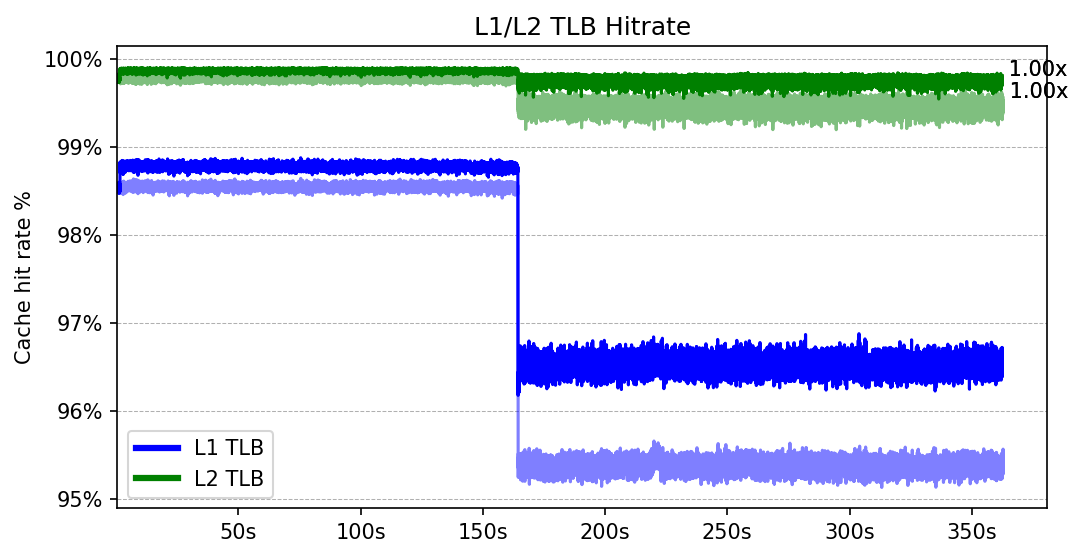

In [3]:
def plot_hitrates(runs, marks):
  fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=150)
  starts = []
  ends = []

  for m in marks:
    ends.append(marks[m] * 1e9)


  endpoints = [] # [(x, y)]
  # axs = axs[0]
  for (run, kwargs) in runs:
    hitrate_file = f"../htlb_sim/results/{run}/hitrate.csv"

    try:
      df = pd.read_csv(hitrate_file)
    except FileNotFoundError:
      print(f"File {hitrate_file} not found")
      continue
    start = df['cycle'].min()
    end = df['cycle'].max()

    # if tlb1 is not in the data, compute it
    if 'tlb1' not in df.columns:
      df['tlb1'] = df['l1hit'] / (df['l1hit'] + df['l1miss']) * 100
      df['tlb2'] = df['l2hit'] / (df['l2hit'] + df['l2miss']) * 100
    starts.append(start)
    ends.append(end)

    bits = [
      # ('htlb1', 'L1 HTLB', 'blue'),
      ('tlb1', 'L1 TLB', 'blue'),
      ('tlb2', 'L2 TLB', 'green'),
      # ('l2miss', 'L2 TLB', 'blue'),
      # ('quality', 'Quality Metric', 'red'),
      # ('dcache1', 'D$ Hitrate', 'red'),
    ]
    df['time'] = pd.to_datetime(df['cycle'], unit='ns')

    longest_seconds = 0

    # aux_col = 'localized_objects'
    # aux_desc = 'Total Localized Objects'

    aux_col = 'quality'
    aux_desc = 'quality metric'


    # if aux_col in df.columns:
    #   # df['quality'] = (1 - df['quality']**2) * 100
    #   # df['quality'] = df['quality'] * 100
    #   # plot on the twinx
    #   ax2 = ax.twinx()
    #   g = sns.lineplot(df, x='cycle', y=aux_col, color='red', ax=ax2, alpha=0.5)
    #   g.set_ylabel(aux_desc)
    #   ax2.set_ylim(0, None)
      # g.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))

    # print(df)
    for col, title, color in bits:
      try:
        g = sns.lineplot(df, x='cycle', y=col, color=color, ax=ax, **kwargs)
        g.set_title(title)

        last_cycle = df['cycle'].iloc[-1]
        last_value = df[col].iloc[-1]

        seconds = last_cycle / 1e9
        if seconds > longest_seconds:
          longest_seconds = seconds
      except:
        pass

    for col, title, color in bits:
      # ax.text(last_cycle, last_value, f' {seconds:.1f}s, {last_value:.1f}', rotation=0, color=color, fontsize=10)
      # df[f'{col}_rolling'] = df[col].rolling(window=100).mean()
      # g = sns.lineplot(df, x='cycle', y=f'{col}_rolling', color=color, alpha=1, ax=ax)
      endpoints.append((last_cycle, last_value))
    
    # make a legend from bits
    handles = []
    for col, title, color in bits:
      handles.append(plt.Line2D([0], [0], color=color, lw=3, label=title))
    ax.legend(handles=handles)

    ax.set_title(f'L1/L2 TLB Hitrate')
    # ax.set_ylim(50, 100)
    ax.set_xlabel(None)
    ax.set_ylabel('Cache hit rate %')


    g.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))
    g.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
    g.yaxis.grid(True, which='major', linestyle='--', linewidth=0.5)


    for mark in marks:
      loc = marks[mark]
      ax.axvline(x=loc * 1e9, color='black', linestyle='--')
      # ax.axvline(x=loc * 1e9 - dump_interval, color='black', linestyle='-')
      # get the current lower bound of y axis
      y_min, y_max = ax.get_ylim()
      ax.text(loc * 1e9, 100, f' {mark}', rotation=0, color='black', fontsize=10)
  time_min = max(starts)
  time_max = max(ends)
  ax.set_xlim(time_min, None)



  for (x, y) in endpoints:
    time = x
    slowdown = time / time_max

    ax.text(x, y, f' {slowdown:.2f}x', rotation=0, color='black', fontsize=10)


  plt.savefig('hitrate.pdf')
  plt.savefig('hitrate.png', dpi=300)

  # rightmax = max([ax[1] for ax in rightaxs])
  # for ax, m in rightaxs:
  #   ax.set_ylim(0, rightmax)



def extract_marks(uartlog):
  marks = {}

  with open(uartlog, 'r') as f:
    for line in f:
      # if the line starts with YUKON_TIMESTAMP
      if line.startswith("YUKON_TIMESTAMP"):
        # split the line by space
        parts = line.strip().split(',')
        marks[parts[1]] = int(parts[2]) / 1e9
        print(parts)
    return marks


# marks = {}
# # marks['begin'] = 40
# marks['iter 0'] = 42596179277 / 1e9
# marks['iter 1'] = 71106022976 / 1e9
# marks['iter 2'] = 99536057157 / 1e9

# plot_hitrates([
#   ('cc_nl', "No Localization"),
#   ('cc_loc', "Localization")], marks = marks)


plot_hitrates([
              ('ycsb-workloada', {'alpha': 1.0, 'linestyle': '-'}),
              ('ycsb-workloada_baseline', {'alpha': 0.5, 'linestyle': '-'}),
              # ('ahhhh', {'alpha': 1.0, 'linestyle': '-'}),
              # ('ahhhh_baseline_skew', {'alpha': 0.4, 'linestyle': 'dotted'}),


              # ('ahhhh_x86', {'alpha': 1, 'linestyle': '-'}),
              # ('ahhhh_x86_baseline', {'alpha': 0.4, 'linestyle': 'dotted'}),

              # ('ahhhh_tiny', {'alpha': 1, 'linestyle': '-'}),
              # ('ahhhh_tiny_baseline', {'alpha': 0.4, 'linestyle': 'dotted'}),
              ],
              # marks={'localization start': 8}
              marks={}
              )

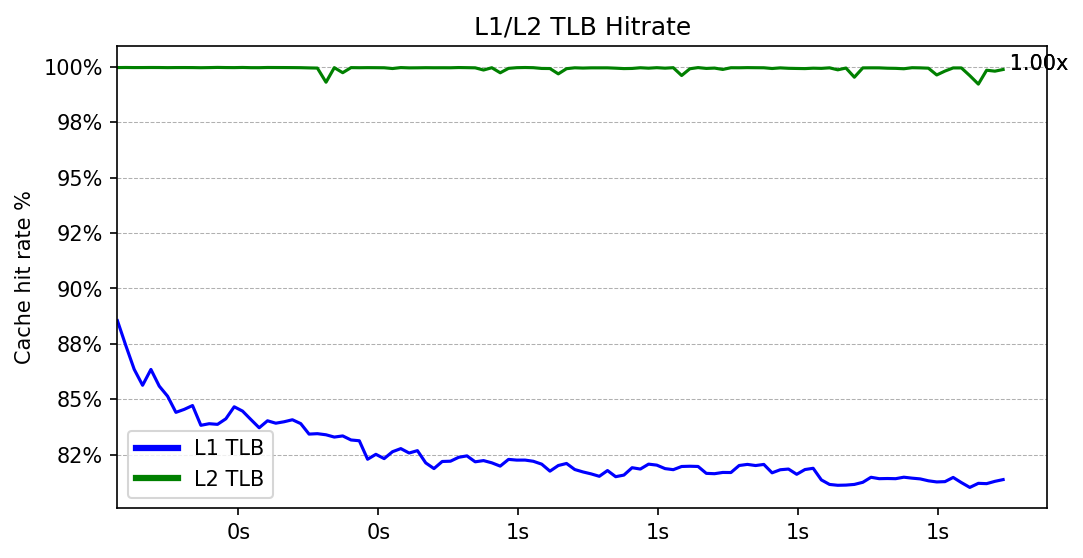

In [8]:
plot_hitrates([('kcore', {'alpha': 1.0, 'linestyle': '-'})], marks={})